In [1]:
from scipy.interpolate import interp1d
from functions_aux import chi2_theoretical
import numpy as np
mag = np.array([
    12.0, 12.5, 13.0, 13.5, 14.0, 14.5,
    15.0, 15.5, 16.0, 16.5, 17.0, 17.5,
    18.0, 18.5, 19.0, 19.5, 20.0, 20.5,
    21.0, 21.5, 22.0, 22.5, 23.0, 23.5,
    24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0
])

sigma_W149 = np.array([
    0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
    0.0010475, 0.0011229, 0.0012038, 0.0013207,
    0.0015178, 0.0017852, 0.002139, 0.0025867,
    0.0032066, 0.0039261, 0.0050352, 0.0063881,
    0.0082817, 0.01087, 0.014603, 0.019616,
    0.027602, 0.039749, 0.058585, 0.088371,
    0.13351, 0.20964, 0.32165, 0.51373, 1.0
])

# Interpolación en log10(sigma)
sigma_interp_log = interp1d(
    mag,
    np.log10(sigma_W149),
    kind="linear",
    bounds_error=True
)

def sigma_W149_func(W149):
    """
    Devuelve sigma_W149 [mag / 15 min] para una magnitud W149.

    Válido para 12 <= W149 <= 27.
    """
    W149 = np.asarray(W149)

    log_sigma = sigma_interp_log(W149)
    sigma = 10**log_sigma

    return sigma


def sigma_flux_from_sigma_mag(mag, sigma_mag, zp=0.0):
    F = mag_to_flux(mag, zp)
    sigma_F = 0.921034 * F * sigma_mag
    return sigma_F

ZP=27.615
def flux_to_mag(flux, zp=ZP):
    flux = np.asarray(flux)
    return zp - 2.5 * np.log10(flux)

def sigma_flux_from_flux(flux, zp=ZP):
    """
    Devuelve el error absoluto en flujo usando la curva sigma_W149(mag).
    
    Requiere que sigma_W149_func(mag) ya esté definida.
    """
    flux = np.asarray(flux)

    mag = flux_to_mag(flux, zp=zp)
    sigma_mag = sigma_W149_func(mag)

    sigma_flux = (np.log(10) / 2.5) * flux * sigma_mag

    return sigma_flux


Parent Directory: /home/anibal/binary_source
Period  1.5339299776947408 years
converting to  560.2679243530041 days (to use in pyLIMA)
Period  0.2808833628231621 years
converting to  102.59264827115996 days (to use in pyLIMA)
Period  1.5339299776947408 years
converting to  560.2679243530041 days (to use in pyLIMA)
Period  0.2808833628231621 years
converting to  102.59264827115996 days (to use in pyLIMA)
Period  1.5339299776947408 years
converting to  560.2679243530041 days (to use in pyLIMA)
Period  0.2808833628231621 years
converting to  102.59264827115996 days (to use in pyLIMA)
Period  1.5339299776947408 years
converting to  560.2679243530041 days (to use in pyLIMA)
Period  0.2808833628231621 years
converting to  102.59264827115996 days (to use in pyLIMA)


In [2]:

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from pyLIMA import event, telescopes
from pyLIMA.models import PSPL_model
from pyLIMA.simulations import simulator
from matplotlib.ticker import AutoMinorLocator


import scipy.optimize as so
def chi2_theoretical(fit_params,target_model, A_true,
                     fs_fixed=1.0, ftotal_fixed=1.0):
    """
    SSE (sin pesos): compara data vs modelo.
    fit_params = [t0,u0,tE]
    Fija flujos: fsource=fs_fixed, ftotal=ftotal_fixed (porque blend_flux_parameter='ftotal' default).
    """
    fit_params = np.asarray(fit_params, dtype=float)
    full_params = np.concatenate([fit_params, [fs_fixed, ftotal_fixed]])

    py_params = target_model.compute_pyLIMA_parameters(full_params)

    sse = 0.0

    telescope = target_model.event.telescopes[0]

    model_pred = target_model.model_magnification(telescope, py_params)
    
    resid = A_true - model_pred
    sse += np.sum(resid**2)

    return float(sse)


def fit_pspl(ev,A_truth, t0_true, u0_true, tE_true, fs, ftotal):
    model_pspl = PSPL_model.PSPLmodel(ev, parallax=["None", 0.0], double_source=["None", 0.0])
    model_pspl.define_model_parameters()

    x0 = np.array([t0_true, u0_true, tE_true], dtype=float)
    
    res = so.minimize(
        chi2_theoretical,
        x0=x0,
        args=(model_pspl, A_truth, fs, ftotal),  
        method="Nelder-Mead",
        options=dict(maxiter=200000, xatol=1e-10, fatol=1e-6),
    )
    print("Fit success")
    if not res.success:
        raise RuntimeError(f"Fit failed: {res.message}")

    best = np.asarray(res.x, dtype=float)

    # reconstruct fitted curves
    best_full = np.concatenate([best, [fs, ftotal]])
    
    t0_ml, u0_ml, tE_ml = best_full[0],best_full[1],best_full[2]
    py_best = model_pspl.compute_pyLIMA_parameters(best_full)
    
    A_fit   = model_pspl.model_magnification(ev.telescopes[0], py_best)

    # residuals
    resid_A = A_truth - A_fit
    return A_fit, best
    
# ============================================================
# Funciones básicas
# ============================================================

def mag_to_flux(mag, zp=0.0):
    return 10**(-0.4 * (mag - zp))


def mag(zp, Flux):
    return zp - 2.5 * np.log10(np.abs(Flux))


def build_sim_event(t, mag0=19.0, emag=1e-9, filt="G"):
    ev = event.Event()
    ev.name = "Simulated"
    ev.ra = 170
    ev.dec = -70

    lc = np.c_[t, np.full_like(t, mag0), np.full_like(t, emag)]

    tel = telescopes.Telescope(
        name="Simulation",
        camera_filter=filt,
        lightcurve=lc.astype(float),
        lightcurve_names=["time", "mag", "err_mag"],
        lightcurve_units=["JD", "mag", "mag"],
        location="Earth",
    )

    ev.telescopes.append(tel)

    return ev


# ============================================================
# Ley de Kepler para fuente binaria circular
# ============================================================


def thetaE_from_lens_mass(M_lens_Msun, Dl_kpc=4.0, Ds_kpc=8.0):
    """
    theta_E [mas] a partir de la masa de la lente y la geometría lente-fuente.

    theta_E^2 = kappa * M_L * pi_rel

    con:
    - kappa = 8.144 mas / Msun
    - pi_rel [mas] = 1/D_l[kpc] - 1/D_s[kpc]

    Nota: si sacamos el deslizador de Ds, dejamos Ds_kpc fijo por defecto.
    """
    if Dl_kpc <= 0 or Ds_kpc <= 0:
        raise ValueError("Dl_kpc y Ds_kpc deben ser positivos.")
    if Dl_kpc >= Ds_kpc:
        raise ValueError("Debe cumplirse Dl_kpc < Ds_kpc.")

    kappa_mas_per_Msun = 8.144
    pi_rel_mas = 1.0 / Dl_kpc - 1.0 / Ds_kpc

    thetaE_mas = np.sqrt(kappa_mas_per_Msun * M_lens_Msun * pi_rel_mas)

    return thetaE_mas, pi_rel_mas


def kepler_binary_source_xiE(
    P_days,
    q_mass,
    Mtot_source_Msun=1.8,
    M_lens_Msun=0.3,
    Dl_kpc=4.0,
    Ds_kpc=8.0,
    tE_days=20.0,
    xi_source="source1",
):
    """
    Calcula xi_E compatible con la tercera ley de Kepler
    usando la masa total de la fuente binaria y la masa de la lente.

    Convenciones:
    - Mtot_source_Msun = M1 + M2, masa total de la fuente binaria.
    - q_mass = M2 / M1.
    - M_lens_Msun es la masa de la lente.
    - P_days en días.
    - Dl_kpc y Ds_kpc en kpc.

    A partir de Mtot_source_Msun y q_mass se reconstruyen:

        M1 = Mtot / (1 + q)
        M2 = q Mtot / (1 + q)

    Ley de Kepler para la fuente binaria:

        a_rel^3 = M_tot * P_yr^2

    con:
    - a_rel en AU
    - M_tot en Msun
    - P_yr en años

    Luego:

        xi_E = a_source / R_E,S

    donde:

        R_E,S [AU] = theta_E [mas] * Ds [kpc]

    porque 1 mas a 1 kpc corresponde a 1 AU.

    Importante:
    - El deslizador M_lens modifica theta_E y por lo tanto xi_E.
    - El deslizador Mtot_source_Msun modifica la separación orbital física.
    - tE_days sigue siendo la escala temporal del modelo.
    - mu_rel no es un parámetro independiente: se calcula como

          mu_rel = theta_E / t_E

      en unidades de mas/yr.
    """

    P_yr = P_days / 365.25

    # Reconstrucción de las masas individuales desde Mtot y q = M2/M1.
    M1_Msun = Mtot_source_Msun / (1.0 + q_mass)
    M2_Msun = q_mass * M1_Msun

    # Separación relativa entre las dos fuentes
    a_rel_AU = (Mtot_source_Msun * P_yr**2)**(1.0 / 3.0)

    # Radios orbitales respecto del baricentro
    a1_AU = a_rel_AU * M2_Msun / Mtot_source_Msun
    a2_AU = a_rel_AU * M1_Msun / Mtot_source_Msun

    # theta_E ahora se calcula desde la masa de la lente
    thetaE_mas, pi_rel_mas = thetaE_from_lens_mass(
        M_lens_Msun=M_lens_Msun,
        Dl_kpc=Dl_kpc,
        Ds_kpc=Ds_kpc,
    )

    # mu_rel físicamente consistente con la masa de la lente y el tE elegido.
    mu_rel_implied_masyr = 365.25 * thetaE_mas / tE_days

    RE_source_AU = thetaE_mas * Ds_kpc

    if xi_source == "source1":
        a_source_AU = a1_AU
    elif xi_source == "source2":
        a_source_AU = a2_AU
    elif xi_source == "relative":
        a_source_AU = a_rel_AU
    else:
        raise ValueError("xi_source debe ser 'source1', 'source2' o 'relative'.")

    xiE = a_source_AU / RE_source_AU

    return xiE, dict(
        P_days=P_days,
        P_yr=P_yr,
        Mtot_source_Msun=Mtot_source_Msun,
        M1_Msun=M1_Msun,
        M2_Msun=M2_Msun,
        M_lens_Msun=M_lens_Msun,
        q_mass=q_mass,
        a_rel_AU=a_rel_AU,
        a1_AU=a1_AU,
        a2_AU=a2_AU,
        thetaE_mas=thetaE_mas,
        pi_rel_mas=pi_rel_mas,
        Dl_kpc=Dl_kpc,
        Ds_kpc=Ds_kpc,
        RE_source_AU=RE_source_AU,
        tE_model_days=tE_days,
        mu_rel_implied_masyr=mu_rel_implied_masyr,
        xi_source=xi_source,
        xiE=xiE,
    )


# ============================================================
# Modelo: fuente binaria circular + magnificación + trayectorias
# ============================================================

def compute_binary_source_case(
    P_days=800.0,
    t0_true=0.0,
    u0_true=0.01,
    tE_true=20.0,

    # xiE manual
    xiE=0.3,

    # modo Kepler
    use_kepler=True,
    Mtot_source_Msun=1.8, # masa total de la fuente binaria
    M_lens_Msun=0.3,      # masa de la lente
    Dl_kpc=4.0,           # distancia lente fija
    Ds_kpc=8.0,           # distancia fuente fija
    xi_source="source1",

    # geometría xallarap
    theta=0.0,
    phi0=np.pi,
    lambda_xi=0.0,

    # fuente binaria
    q_mass=0.8,
    qflux=0.45,

    # fotometría
    ms=24.0,
    mtotal=24.0,

    # visualización
    window_k=5.0,
    n_points=5000,
):
    """
    Calcula magnificación y trayectorias para una fuente binaria circular
    usando pyLIMA double_source=["Circular", t0].

    Si use_kepler=True:
        xiE se calcula con Kepler.

    Si use_kepler=False:
        xiE se toma directamente del slider xiE.
    """

    t = np.linspace(
        t0_true - window_k * tE_true,
        t0_true + window_k * tE_true,
        int(n_points)
    )

    omega = 2.0 * np.pi / float(P_days)

    if use_kepler:
        xiE_use, kepler_info = kepler_binary_source_xiE(
            P_days=P_days,
            q_mass=q_mass,
            Mtot_source_Msun=Mtot_source_Msun,
            M_lens_Msun=M_lens_Msun,
            Dl_kpc=Dl_kpc,
            Ds_kpc=Ds_kpc,
            tE_days=tE_true,
            xi_source=xi_source,
        )
    else:
        xiE_use = xiE
        kepler_info = None

    xi_para = xiE_use * np.cos(theta)
    xi_perp = xiE_use * np.sin(theta)

    ev = build_sim_event(t, mag0=19.0, emag=1e-9, filt="G")

    model_xal = PSPL_model.PSPLmodel(
        ev,
        parallax=["None", 0.0],
        double_source=["Circular", t0_true]
    )

    model_xal.define_model_parameters()

    ZP = 27.615

    fs = mag_to_flux(ms, zp=ZP)
    ftotal = mag_to_flux(mtotal, zp=ZP)

    params_xal = [
        t0_true,
        u0_true,
        tE_true,
        xi_para,
        xi_perp,
        omega,
        phi0,
        lambda_xi,
        q_mass,
        qflux,
        fs,
        ftotal,
    ]

    py_params_xal = model_xal.compute_pyLIMA_parameters(params_xal)

    simulator.simulate_lightcurve(model_xal, py_params_xal)

    A_truth = model_xal.model_magnification(
        ev.telescopes[0],
        py_params_xal
    ) / (1.0 + qflux)

    F_truth = model_xal.compute_the_microlensing_model(
        ev.telescopes[0],
        py_params_xal
    )["photometry"]

    ev.telescopes[0].lightcurve["flux"] = A_truth
    ev.telescopes[0].lightcurve["mag"] = mag(27.615, F_truth)

    trajectories = model_xal.sources_trajectory(
        model_xal.event.telescopes[0],
        py_params_xal,
        data_type="photometry"
    )

    source1_x, source1_y, source2_x, source2_y, dsep, dalpha = trajectories



    A_fit, best_fit = fit_pspl(
        ev, A_truth, t0_true, u0_true, tE_true, fs, ftotal
    )

    t0_fit, u0_fit, tE_fit = best_fit

    # Métricas de residuales entre el ajuste PSPL y el modelo xallarap.
    resid_A = A_fit - A_truth
    abs_resid_A = np.abs(resid_A)
    rms_abs_resid_A = np.sqrt(np.mean(abs_resid_A**2))
    max_abs_resid_A = np.max(abs_resid_A)

    return dict(
        t=t,
        A=A_truth,
        F=F_truth,
        A_fit=A_fit,

        resid_A=resid_A,
        abs_resid_A=abs_resid_A,
        rms_abs_resid_A=rms_abs_resid_A,
        max_abs_resid_A=max_abs_resid_A,

        best_fit=best_fit,
        t0_fit=t0_fit,
        u0_fit=u0_fit,
        tE_fit=tE_fit,

        t0_true=t0_true,
        u0_true=u0_true,
        tE_true=tE_true,

        delta_t0=t0_fit - t0_true,
        delta_u0=u0_fit - u0_true,
        delta_tE=tE_fit - tE_true,

        frac_delta_tE=(tE_fit - tE_true) / tE_true,
        frac_delta_u0=(u0_fit - u0_true) / u0_true,

        model=model_xal,
        py_params=py_params_xal,

        source1_x=source1_x,
        source1_y=source1_y,
        source2_x=source2_x,
        source2_y=source2_y,
        dseparation=dsep,
        dalpha=dalpha,

        omega=omega,
        xiE_use=xiE_use,
        xi_para=xi_para,
        xi_perp=xi_perp,
        kepler_info=kepler_info,
    )

In [3]:
%matplotlib widget

# ============================================================
# Helpers de graficado
# ============================================================

def _arr(x):
    return np.asarray(getattr(x, "value", x))


def add_direction_arrows(ax, x, y, color, n_arrows=5):
    """
    Agrega flechas sobre una trayectoria para indicar el sentido temporal.
    """
    if x is None or y is None:
        return

    x = _arr(x)
    y = _arr(y)

    if len(x) < 3:
        return

    idxs = np.linspace(1, len(x) - 2, n_arrows, dtype=int)

    for idx in idxs:
        dx = x[idx + 1] - x[idx - 1]
        dy = y[idx + 1] - y[idx - 1]

        norm = np.hypot(dx, dy)

        if norm == 0:
            continue

        scale = 0.08

        ax.annotate(
            "",
            xy=(x[idx] + scale * dx / norm, y[idx] + scale * dy / norm),
            xytext=(x[idx], y[idx]),
            arrowprops=dict(
                arrowstyle="->",
                mutation_scale=14,
                color=color,
                lw=1.5
            )
        )


def build_param_text(
    out,
    P_days,
    tE_true,
    u0_true,
    xiE,
    use_kepler,
    Mtot_source_Msun,
    M_lens_Msun,
    q_mass,
    qflux,
):
    xiE_plot = out["xiE_use"]
    kepler_info = out["kepler_info"]

    if use_kepler and kepler_info is not None:
        param_text = (
            r"$\bf{Keplerian\ binary\ source}$" "\n"
            rf"$P={P_days:.3g}\,\mathrm{{d}}$" "\n"
            rf"$t_E={tE_true:.3g}\,\mathrm{{d}}$" "\n"
            rf"$u_0={u0_true:.3g}$" "\n"
            rf"$M_{{\rm tot}}={Mtot_source_Msun:.3g}\,M_\odot$" "\n"
            rf"$q_M={q_mass:.3g}$" "\n"
            rf"$M_1={kepler_info['M1_Msun']:.3g}\,M_\odot$" "\n"
            rf"$M_2={kepler_info['M2_Msun']:.3g}\,M_\odot$" "\n"
            rf"$M_L={M_lens_Msun:.3g}\,M_\odot$" "\n"
            rf"$D_L={kepler_info['Dl_kpc']:.3g}\,\mathrm{{kpc}}$" "\n"
            rf"$D_s={kepler_info['Ds_kpc']:.3g}\,\mathrm{{kpc}}$" "\n"
            rf"$\pi_\mathrm{{rel}}={kepler_info['pi_rel_mas']:.3g}\,\mathrm{{mas}}$" "\n"
            rf"$\theta_E={kepler_info['thetaE_mas']:.3g}\,\mathrm{{mas}}$" "\n"
            rf"$\mu_\mathrm{{rel}}^\mathrm{{imp}}={kepler_info['mu_rel_implied_masyr']:.3g}\,\mathrm{{mas\,yr^{{-1}}}}$" "\n"
            rf"$a_\mathrm{{rel}}={kepler_info['a_rel_AU']:.3g}\,\mathrm{{AU}}$" "\n"
            rf"$R_{{E,S}}={kepler_info['RE_source_AU']:.3g}\,\mathrm{{AU}}$" "\n"
            rf"$\xi_E={xiE_plot:.3g}$" "\n"
            rf"$q_F={qflux:.3g}$"
        )
    else:
        param_text = (
            r"$\bf{Free\ }\xi_E$" "\n"
            rf"$P={P_days:.3g}\,\mathrm{{d}}$" "\n"
            rf"$t_E={tE_true:.3g}\,\mathrm{{d}}$" "\n"
            rf"$u_0={u0_true:.3g}$" "\n"
            rf"$\xi_E={xiE:.3g}$" "\n"
            rf"$M_{{\rm tot}}={Mtot_source_Msun:.3g}\,M_\odot$" "\n"
            rf"$q_M={q_mass:.3g}$" "\n"
            rf"$q_F={qflux:.3g}$"
        )

    return param_text

def plot_binary_source_widget(
    P_days=800.0,
    t0_true=0.0,
    u0_true=0.01,
    tE_true=20.0,

    xiE=0.3,

    use_kepler=True,
    Mtot_source_Msun=1.8,
    M_lens_Msun=0.3,
    Dl_kpc=4.0,
    Ds_kpc=8.0,
    xi_source="source1",

    theta=0.0,
    phi0=np.pi,
    lambda_xi=0.0,

    q_mass=0.8,
    qflux=0.45,

    window_k=5.0,
    n_points=5000,
    traj_lim=3.0,
    logA=False,
):
    plt.close("all")

    out = compute_binary_source_case(
        P_days=P_days,
        t0_true=t0_true,
        u0_true=u0_true,
        tE_true=tE_true,

        xiE=xiE,

        use_kepler=use_kepler,
        Mtot_source_Msun=Mtot_source_Msun,
        M_lens_Msun=M_lens_Msun,
        Dl_kpc=Dl_kpc,
        Ds_kpc=Ds_kpc,
        xi_source=xi_source,

        theta=theta,
        phi0=phi0,
        lambda_xi=lambda_xi,

        q_mass=q_mass,
        qflux=qflux,

        ms=24.0,
        mtotal=24.0,

        window_k=window_k,
        n_points=n_points,
    )

    t = out["t"]
    A = out["A"]
    A_fit = out["A_fit"]
    resid_A = out["resid_A"]

    rms_abs_resid_A = out["rms_abs_resid_A"]
    max_abs_resid_A = out["max_abs_resid_A"]


    delay_info = measure_binary_source_peak_delay(
    out,
    tE_days=tE_true,
    prominence_frac=0.05)

    s1x = out["source1_x"]
    s1y = out["source1_y"]
    s2x = out["source2_x"]
    s2y = out["source2_y"]

    # ============================================================
    # Layout:
    # izquierda arriba: magnificación
    # izquierda abajo: residuos
    # derecha: trayectorias, ocupando ambas filas
    # ============================================================

    fig = plt.figure(figsize=(16, 7.4))

    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=[1.35, 1.0],
        height_ratios=[3.2, 1.2],
        wspace=0.28,
        hspace=0.06,
    )

    axA = fig.add_subplot(gs[0, 0])
    axR = fig.add_subplot(gs[1, 0], sharex=axA)
    axT = fig.add_subplot(gs[:, 1])

    # ============================================================
    # Columna izquierda arriba: magnificación
    # ============================================================

    if logA:
        axA.plot(t, np.log10(A), lw=1.8, label="Xallarap")
        axA.plot(
            t,
            np.log10(A_fit),
            lw=1.8,
            alpha=0.7,
            color="red",
            linestyle="--",
            label="PSPL fit",
        )
        axA.set_ylabel(r"$\log_{10} A(t)$")
    else:
        axA.plot(t, A, lw=1.8, label="Xallarap")
        axA.plot(
            t,
            A_fit,
            lw=1.8,
            alpha=0.7,
            color="red",
            linestyle="--",
            label="PSPL fit",
        )
        axA.set_ylabel(r"$A(t)$")

    axA.axvline(t0_true, ls=":", lw=1.2, color="k", alpha=0.7)

    axA.set_title("Magnification and PSPL residuals")
    axA.legend(frameon=False, loc="best")
    axA.grid(alpha=0.25)

    plt.setp(axA.get_xticklabels(), visible=False)

    # ============================================================
    # Caja de métricas
    # ============================================================

    metrics_text = (
        r"$\bf{Metrics}$" "\n"
        r"$r_A=A_\mathrm{PSPL}-A_\mathrm{xallarap}$" "\n"
        rf"$\mathrm{{RMS}}(|r_A|)={rms_abs_resid_A:.3e}$" "\n"
        rf"$\max(|r_A|)={max_abs_resid_A:.3e}$"
    )

    axA.annotate(
        metrics_text,
        xy=(0.97, 0.97),
        xycoords="axes fraction",
        va="top",
        ha="right",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc="white",
            ec="0.5",
            alpha=0.9,
        ),
    )

    # ============================================================
    # Caja de parámetros
    # ============================================================

    param_text = build_param_text(
        out=out,
        P_days=P_days,
        tE_true=tE_true,
        u0_true=u0_true,
        xiE=xiE,
        use_kepler=use_kepler,
        Mtot_source_Msun=Mtot_source_Msun,
        M_lens_Msun=M_lens_Msun,
        q_mass=q_mass,
        qflux=qflux,
    )

    axA.text(
        0.03,
        0.97,
        param_text,
        transform=axA.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc="white",
            ec="0.5",
            alpha=0.9,
        ),
    )

    # ============================================================
    # Columna izquierda abajo: residuos
    # ============================================================

    axR.plot(t, resid_A, lw=1.4)
    axR.axhline(0.0, linestyle=":", linewidth=1.0, color="k", alpha=0.8)
    axR.axvline(t0_true, ls=":", lw=1.0, color="k", alpha=0.5)

    axR.set_xlabel("Time [days]")
    axR.set_ylabel(r"$\Delta A$")

    axR.grid(alpha=0.25)

    axA.yaxis.set_minor_locator(AutoMinorLocator())
    axR.yaxis.set_minor_locator(AutoMinorLocator())
    axR.xaxis.set_minor_locator(AutoMinorLocator())

    # ============================================================
    # Columna derecha: trayectorias
    # ============================================================

    ph = np.linspace(0, 2 * np.pi, 300)

    axT.plot(
        np.cos(ph),
        np.sin(ph),
        "k--",
        lw=1.2,
        label=r"$\theta_E$",
    )

    if s1x is not None and s1y is not None:
        axT.plot(_arr(s1x), _arr(s1y), lw=1.8, color="C0", label="Source 1")
        add_direction_arrows(axT, s1x, s1y, color="C0")

    if s2x is not None and s2y is not None:
        axT.plot(_arr(s2x), _arr(s2y), lw=1.8, color="C1", label="Source 2")
        add_direction_arrows(axT, s2x, s2y, color="C1")

    axT.scatter([0], [0], marker="+", s=90, color="k", label="Lens")

    axT.axhline(0, lw=0.8, color="k", alpha=0.4)
    axT.axvline(0, lw=0.8, color="k", alpha=0.4)

    axT.set_aspect("equal", adjustable="box")

    axT.set_xlim(-traj_lim, traj_lim)
    axT.set_ylim(-traj_lim, traj_lim)

    axT.set_xlabel(r"$u_x$")
    axT.set_ylabel(r"$u_y$")
    axT.set_title("Source trajectories")

    axT.legend(frameon=False, fontsize=9)
    axT.grid(alpha=0.25)

# ============================================================
# Marcas de tiempos de pico de cada fuente
# ============================================================
    
    axA.axvline(
        delay_info["t_peak_geom_1"],
        color="C0",
        ls=":",
        lw=1.4,
        alpha=0.9,
        label="min u1"
    )
    
    axA.axvline(
        delay_info["t_peak_geom_2"],
        color="C1",
        ls=":",
        lw=1.4,
        alpha=0.9,
        label="min u2"
    )
    
    if np.isfinite(delay_info["t_A_peak_1"]):
        axA.axvline(
            delay_info["t_A_peak_1"],
            color="gray",
            ls="--",
            lw=1.2,
            alpha=0.7
        )
    
    if np.isfinite(delay_info["t_A_peak_2"]):
        axA.axvline(
            delay_info["t_A_peak_2"],
            color="gray",
            ls="--",
            lw=1.2,
            alpha=0.7
        )


    plt.show()


from scipy.signal import find_peaks

def measure_binary_source_peak_delay(out, tE_days=None, prominence_frac=0.05):
    """
    Mide y predice la separación temporal entre los dos picos de una fuente binaria.

    Devuelve:
    - dt_geom_days:
        diferencia entre los tiempos de mínimo u(t) de source 1 y source 2.
        Es la medida geométrica más limpia.
    - dt_A_days:
        diferencia entre los dos picos más prominentes de la curva A(t), si existen.
        Es lo observable en la luz total.
    - dt_pred_proj_days:
        predicción usando la separación proyectada paralela a la trayectoria.
    - dt_scale_days:
        escala máxima xi_E_rel * tE, sin factor coseno.
    - tau_a_days:
        a_rel / (Ds mu_rel), calculado desde Kepler info, si existe.
    """

    t = _arr(out["t"])

    r1 = np.column_stack([
        _arr(out["source1_x"]),
        _arr(out["source1_y"])
    ])

    r2 = np.column_stack([
        _arr(out["source2_x"]),
        _arr(out["source2_y"])
    ])

    # ------------------------------------------------------------
    # 1) Tiempos de máximo individuales: mínimo u_i(t)
    # ------------------------------------------------------------

    u1 = np.linalg.norm(r1, axis=1)
    u2 = np.linalg.norm(r2, axis=1)

    i1 = np.nanargmin(u1)
    i2 = np.nanargmin(u2)

    t_peak_geom_1 = t[i1]
    t_peak_geom_2 = t[i2]

    dt_geom_days = np.abs(t_peak_geom_2 - t_peak_geom_1)

    # ------------------------------------------------------------
    # 2) Dirección de movimiento lente-fuente
    # ------------------------------------------------------------
    # Estimamos la dirección común ajustando una recta al punto medio.
    # Esto funciona bien si el movimiento orbital no domina la deriva lineal.
    # Para órbitas muy rápidas, esta predicción deja de ser exacta.

    rmid = 0.5 * (r1 + r2)

    vx = np.polyfit(t, rmid[:, 0], 1)[0]
    vy = np.polyfit(t, rmid[:, 1], 1)[0]

    speed = np.hypot(vx, vy)

    if speed > 0:
        vhat = np.array([vx, vy]) / speed
    else:
        vhat = np.array([1.0, 0.0])

    # Tomo la separación de las fuentes cerca del punto medio entre ambos picos.
    tref = 0.5 * (t_peak_geom_1 + t_peak_geom_2)
    jref = np.nanargmin(np.abs(t - tref))

    du_vec = r2[jref] - r1[jref]
    du_rel = np.linalg.norm(du_vec)
    du_parallel = np.dot(du_vec, vhat)

    if tE_days is not None:
        dt_pred_proj_days = np.abs(du_parallel) * tE_days
        dt_scale_days = du_rel * tE_days
    else:
        dt_pred_proj_days = np.abs(du_parallel) / speed
        dt_scale_days = du_rel / speed

    cospsi = np.abs(du_parallel) / du_rel if du_rel > 0 else np.nan

    # ------------------------------------------------------------
    # 3) Medida observable en la curva de magnificación total
    # ------------------------------------------------------------

    A = _arr(out["A"])

    A_range = np.nanmax(A) - np.nanmedian(A)

    dt_A_days = np.nan
    t_A_peak_1 = np.nan
    t_A_peak_2 = np.nan

    if A_range > 0:
        prominence = prominence_frac * A_range
        min_distance = max(1, int(0.01 * len(t)))

        peaks, props = find_peaks(
            A,
            prominence=prominence,
            distance=min_distance
        )

        if len(peaks) >= 2:
            # Tomo los dos picos más altos.
            best = peaks[np.argsort(A[peaks])[-2:]]
            best = np.sort(best)

            t_A_peak_1 = t[best[0]]
            t_A_peak_2 = t[best[1]]
            dt_A_days = np.abs(t_A_peak_2 - t_A_peak_1)

    # ------------------------------------------------------------
    # 4) Escala física a_rel / (Ds mu_rel)
    # ------------------------------------------------------------

    tau_a_days = np.nan
    xi_rel_from_kepler = np.nan

    kepler_info = out.get("kepler_info", None)

    if kepler_info is not None:
        a_rel_AU = kepler_info.get("a_rel_AU", np.nan)
        Ds_kpc = kepler_info.get("Ds_kpc", np.nan)
        mu_rel_masyr = kepler_info.get("mu_rel_implied_masyr", np.nan)
        RE_source_AU = kepler_info.get("RE_source_AU", np.nan)

        if np.isfinite(a_rel_AU) and np.isfinite(Ds_kpc) and np.isfinite(mu_rel_masyr):
            tau_a_days = 365.25 * a_rel_AU / (Ds_kpc * mu_rel_masyr)

        if np.isfinite(a_rel_AU) and np.isfinite(RE_source_AU) and RE_source_AU > 0:
            xi_rel_from_kepler = a_rel_AU / RE_source_AU

    return dict(
        t_peak_geom_1=t_peak_geom_1,
        t_peak_geom_2=t_peak_geom_2,
        dt_geom_days=dt_geom_days,

        t_A_peak_1=t_A_peak_1,
        t_A_peak_2=t_A_peak_2,
        dt_A_days=dt_A_days,

        du_rel=du_rel,
        du_parallel=du_parallel,
        cospsi=cospsi,

        dt_pred_proj_days=dt_pred_proj_days,
        dt_scale_days=dt_scale_days,

        tau_a_days=tau_a_days,
        xi_rel_from_kepler=xi_rel_from_kepler,
    )
# ============================================================
# Sliders
# ============================================================

style = {"description_width": "120px"}
layout = widgets.Layout(width="380px")


# Sliders angulares con labels tipo múltiplos de pi.
# Uso unicode porque ipywidgets no siempre renderiza LaTeX en labels.

pi_options_0_2pi = [
    ("0", 0.0),
    ("π/4", np.pi/4),
    ("π/2", np.pi/2),
    ("3π/4", 3*np.pi/4),
    ("π", np.pi),
    ("5π/4", 5*np.pi/4),
    ("3π/2", 3*np.pi/2),
    ("7π/4", 7*np.pi/4),
    ("2π", 2*np.pi),
]

pi_options_0_pi = [
    ("0", 0.0),
    ("π/6", np.pi/6),
    ("π/4", np.pi/4),
    ("π/3", np.pi/3),
    ("π/2", np.pi/2),
    ("2π/3", 2*np.pi/3),
    ("3π/4", 3*np.pi/4),
    ("5π/6", 5*np.pi/6),
    ("π", np.pi),
]


sliders = dict(
    P_days=widgets.FloatLogSlider(
        value=800.0,
        base=10,
        min=np.log10(10),
        max=np.log10(3000),
        step=0.02,
        description="P [days]",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    t0_true=widgets.FloatSlider(
        value=0.0,
        min=-100.0,
        max=100.0,
        step=1.0,
        description="t0 [days]",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    u0_true=widgets.FloatLogSlider(
        value=0.01,
        base=10,
        min=-3,
        max=np.log10(2),
        step=0.02,
        description="u0",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    tE_true=widgets.FloatSlider(
        value=20.0,
        min=1.0,
        max=800.0,
        step=1.0,
        description="tE [days]",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    xiE=widgets.FloatSlider(
        value=0.3,
        min=0.0,
        max=3.0,
        step=0.01,
        description="xiE manual",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    use_kepler=widgets.Checkbox(
        value=True,
        description="Kepler mode",
        indent=False,
        layout=widgets.Layout(width="200px")
    ),

    Mtot_source_Msun=widgets.FloatLogSlider(
        value=1.8,
        base=10,
        min=np.log10(0.05),
        max=np.log10(20.0),
        step=0.02,
        description="Mtot src [Msun]",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    M_lens_Msun=widgets.FloatLogSlider(
        value=0.3,
        base=10,
        min=-12,
        max=np.log10(10.0),
        step=0.02,
        description="M lens [Msun]",
        style=style,
        layout=layout,
        continuous_update=False,
        readout=True,
        readout_format=".1e",
    ),

    xi_source=widgets.Dropdown(
        options=[
            ("source 1", "source1"),
            ("source 2", "source2"),
            ("relative", "relative"),
        ],
        value="source1",
        description="xi source",
        style=style,
        layout=layout
    ),

    theta=widgets.SelectionSlider(
        options=pi_options_0_2pi,
        value=0.0,
        description="theta",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    phi0=widgets.SelectionSlider(
        options=pi_options_0_2pi,
        value=np.pi,
        description="phi0",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    lambda_xi=widgets.SelectionSlider(
        options=pi_options_0_2pi,
        value=0.0,
        description="lambda",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    q_mass=widgets.FloatLogSlider(
    value=0.1,
    base=10,
    min=-6,
    max=np.log10(2.0),
    step=0.02,
    description="q mass",
    style=style,
    layout=layout,
    continuous_update=False,
    readout=True,
    readout_format=".1e",
    ),

    qflux=widgets.FloatSlider(
        value=0.45,
        min=0.0,
        max=2.0,
        step=0.01,
        description="q flux",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    window_k=widgets.FloatSlider(
        value=5.0,
        min=0.5,
        max=15.0,
        step=0.5,
        description="window [tE]",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    n_points=widgets.IntSlider(
        value=5000,
        min=1000,
        max=30000,
        step=1000,
        description="N points",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    traj_lim=widgets.FloatSlider(
        value=3.0,
        min=0.25,
        max=10.0,
        step=0.25,
        description="traj lim",
        style=style,
        layout=layout,
        continuous_update=False
    ),

    logA=widgets.Checkbox(
        value=False,
        description="plot log10(A)",
        indent=False,
        layout=widgets.Layout(width="200px")
    )
)


# ============================================================
# Layout del widget
# ============================================================

ui_orbit = widgets.VBox([
    widgets.HTML("<b>Microlensing parameters</b>"),
    sliders["P_days"],
    sliders["t0_true"],
    sliders["u0_true"],
    sliders["tE_true"],
    sliders["xiE"],
])

ui_kepler = widgets.VBox([
    widgets.HTML("<b>Kepler parameters</b>"),
    sliders["use_kepler"],
    sliders["Mtot_source_Msun"],
    sliders["M_lens_Msun"],
    sliders["xi_source"],
])

ui_geometry = widgets.VBox([
    widgets.HTML("<b>Geometry and binary source</b>"),
    sliders["theta"],
    sliders["phi0"],
    sliders["lambda_xi"],
    sliders["q_mass"],
    sliders["qflux"],
])

ui_plot = widgets.VBox([
    widgets.HTML("<b>Plot options</b>"),
    sliders["window_k"],
    sliders["n_points"],
    sliders["traj_lim"],
    sliders["logA"],
])

ui = widgets.HBox([
    ui_orbit,
    ui_kepler,
    ui_geometry,
    ui_plot,
])

out_plot = widgets.interactive_output(
    plot_binary_source_widget,
    sliders
)

display(ui, out_plot)

Output()

Fit success
ML=0.100  tE=29.1d  xiE=0.0694  P/tE=3.4324  RMS=1.241e-03
Fit success
ML=0.127  tE=32.9d  xiE=0.0615  P/tE=3.0406  RMS=9.584e-04
Fit success
ML=0.162  tE=37.1d  xiE=0.0544  P/tE=2.6936  RMS=7.351e-04
Fit success
ML=0.207  tE=41.9d  xiE=0.0482  P/tE=2.3862  RMS=5.607e-04
Fit success
ML=0.264  tE=47.3d  xiE=0.0427  P/tE=2.1138  RMS=4.264e-04
Fit success
ML=0.336  tE=53.4d  xiE=0.0378  P/tE=1.8726  RMS=3.246e-04
Fit success
ML=0.428  tE=60.3d  xiE=0.0335  P/tE=1.6588  RMS=2.490e-04
Fit success
ML=0.546  tE=68.0d  xiE=0.0297  P/tE=1.4695  RMS=1.938e-04
Fit success
ML=0.695  tE=76.8d  xiE=0.0263  P/tE=1.3018  RMS=1.540e-04
Fit success
ML=0.886  tE=86.7d  xiE=0.0233  P/tE=1.1532  RMS=1.249e-04
Fit success
ML=1.129  tE=97.9d  xiE=0.0206  P/tE=1.0216  RMS=1.029e-04
Fit success
ML=1.438  tE=110.5d  xiE=0.0183  P/tE=0.9050  RMS=8.506e-05
Fit success
ML=1.833  tE=124.7d  xiE=0.0162  P/tE=0.8017  RMS=6.979e-05
Fit success
ML=2.336  tE=140.8d  xiE=0.0144  P/tE=0.7102  RMS=5.631e-05
Fit

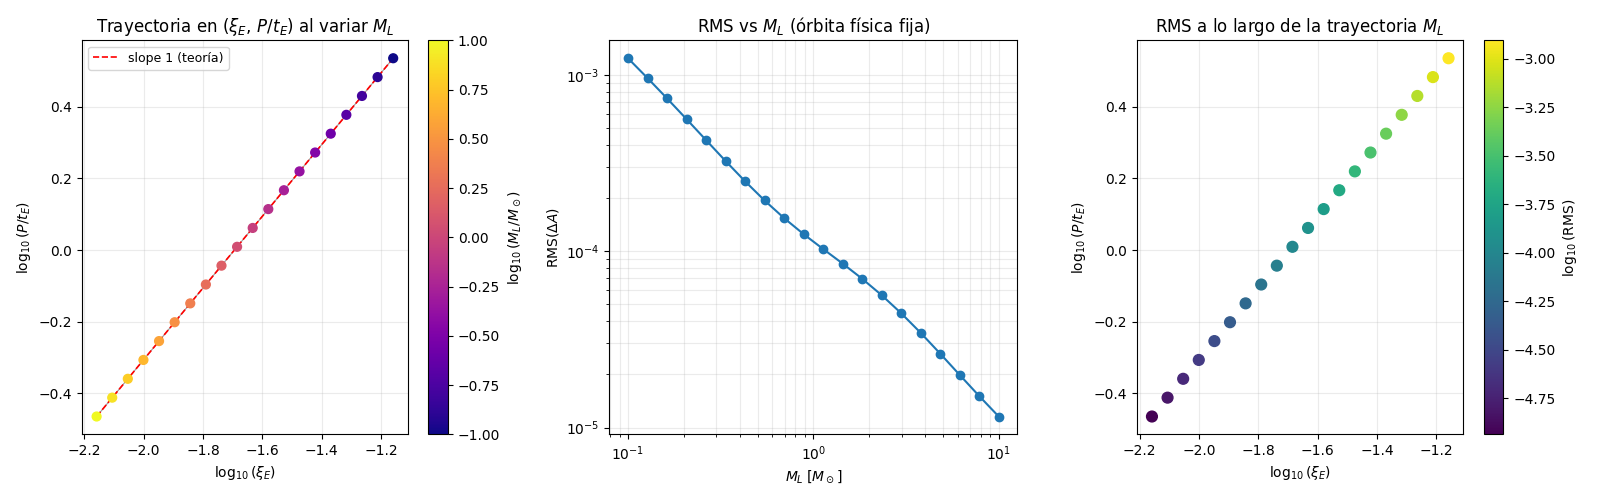

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def scan_ML(
    M_lens_array,           # grilla de M_L a barrer
    P_days=100.0,           # período físico fijo
    t0_true=0.0,
    u0_true=0.3,
    tE_true=50.0,           # tE de referencia (se recomputa internamente vía mu_rel)
    Mtot_source_Msun=2.0,
    Dl_kpc=4.0,
    Ds_kpc=8.0,
    q_mass=0.5,
    qflux=0.5,
    theta=0.0,
    phi0=np.pi,
    lambda_xi=0.0,
    xi_source="source1",
    n_points=3000,
    window_k=5.0,
):
    results = []
    for ML in M_lens_array:
        try:
            out = compute_binary_source_case(
                P_days=P_days,
                t0_true=t0_true,
                u0_true=u0_true,
                tE_true=tE_true,
                use_kepler=True,
                Mtot_source_Msun=Mtot_source_Msun,
                M_lens_Msun=ML,
                Dl_kpc=Dl_kpc,
                Ds_kpc=Ds_kpc,
                q_mass=q_mass,
                qflux=qflux,
                theta=theta,
                phi0=phi0,
                lambda_xi=lambda_xi,
                xi_source=xi_source,
                n_points=n_points,
                window_k=window_k,
            )
            ki = out["kepler_info"]
            results.append(dict(
                ML        = ML,
                xiE       = out["xiE_use"],
                tE        = ki["tE_model_days"],   # tE que implica este ML
                PtE       = P_days / ki["tE_model_days"],
                rms       = out["rms_abs_resid_A"],
                max_resid = out["max_abs_resid_A"],
            ))
            print(f"ML={ML:.3f}  xiE={out['xiE_use']:.4f}  P/tE={P_days/ki['tE_model_days']:.4f}  RMS={out['rms_abs_resid_A']:.3e}")
        except Exception as e:
            print(f"ML={ML:.3f}  ERROR: {e}")
    return results
def scan_ML_fixed_murel(
    M_lens_array,
    mu_rel_masyr = 4.0,    # fijo
    P_days       = 100.0,
    Dl_kpc       = 4.0,
    Ds_kpc       = 8.0,
    Mtot_source_Msun = 2.0,
    q_mass       = 0.5,
    qflux        = 0.5,
    u0_true      = 0.3,
    t0_true      = 0.0,
    **kwargs
):
    results = []
    for ML in M_lens_array:
        # 1. theta_E desde M_L
        thetaE_mas, _ = thetaE_from_lens_mass(ML, Dl_kpc, Ds_kpc)

        # 2. tE como output
        tE_computed = thetaE_mas / mu_rel_masyr * 365.25   # días

        # 3. llamada normal con tE_computed
        out = compute_binary_source_case(
            P_days           = P_days,
            t0_true          = t0_true,
            u0_true          = u0_true,
            tE_true          = tE_computed,   # <-- ya no es fijo
            use_kepler       = True,
            Mtot_source_Msun = Mtot_source_Msun,
            M_lens_Msun      = ML,
            Dl_kpc           = Dl_kpc,
            Ds_kpc           = Ds_kpc,
            q_mass           = q_mass,
            qflux            = qflux,
            **kwargs
        )
        ki = out["kepler_info"]
        results.append(dict(
            ML    = ML,
            xiE   = out["xiE_use"],
            tE    = tE_computed,
            PtE   = P_days / tE_computed,
            rms   = out["rms_abs_resid_A"],
        ))
        print(f"ML={ML:.3f}  tE={tE_computed:.1f}d  "
              f"xiE={out['xiE_use']:.4f}  "
              f"P/tE={P_days/tE_computed:.4f}  "
              f"RMS={out['rms_abs_resid_A']:.3e}")
    return results

def plot_ML_scan(results):
    ML_arr  = np.array([r["ML"]        for r in results])
    xiE_arr = np.array([r["xiE"]       for r in results])
    PtE_arr = np.array([r["PtE"]       for r in results])
    rms_arr = np.array([r["rms"]       for r in results])

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── Panel 1: trayectoria en el plano (log xiE, log P/tE) ──────────────
    ax = axes[0]
    sc = ax.scatter(
        np.log10(xiE_arr), np.log10(PtE_arr),
        c=np.log10(ML_arr), cmap="plasma",
        s=40, zorder=3
    )
    ax.plot(np.log10(xiE_arr), np.log10(PtE_arr), "k-", lw=0.8, alpha=0.4)

    # línea de pendiente 1 esperada (referencia teórica)
    offset = np.log10(PtE_arr[0]) - np.log10(xiE_arr[0])  # offset real
    x_ref = np.linspace(np.log10(xiE_arr.min()), np.log10(xiE_arr.max()), 50)
    ax.plot(x_ref, x_ref + offset, "r--", lw=1.2, label="slope 1 (teoría)")
    # x_ref = np.linspace(np.log10(xiE_arr.min()), np.log10(xiE_arr.max()), 50)
    # ax.plot(x_ref, x_ref - x_ref[0] + np.log10(PtE_arr[0]),
            # "r--", lw=1.2, label="slope 1 (teoría)")

    plt.colorbar(sc, ax=ax, label=r"$\log_{10}(M_L/M_\odot)$")
    ax.set_xlabel(r"$\log_{10}(\xi_E)$")
    ax.set_ylabel(r"$\log_{10}(P/t_E)$")
    ax.set_title(r"Trayectoria en $(\xi_E,\,P/t_E)$ al variar $M_L$")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

    # ── Panel 2: RMS vs M_L ───────────────────────────────────────────────
    ax = axes[1]
    ax.loglog(ML_arr, rms_arr, "o-", lw=1.5)
    ax.set_xlabel(r"$M_L\;[M_\odot]$")
    ax.set_ylabel(r"$\mathrm{RMS}(\Delta A)$")
    ax.set_title(r"RMS vs $M_L$ (órbita física fija)")
    ax.grid(alpha=0.25, which="both")

    # ── Panel 3: RMS en el plano (log xiE, log P/tE) ─────────────────────
    ax = axes[2]
    sc2 = ax.scatter(
        np.log10(xiE_arr), np.log10(PtE_arr),
        c=np.log10(rms_arr), cmap="viridis",
        s=60, zorder=3
    )
    plt.colorbar(sc2, ax=ax, label=r"$\log_{10}(\mathrm{RMS})$")
    ax.set_xlabel(r"$\log_{10}(\xi_E)$")
    ax.set_ylabel(r"$\log_{10}(P/t_E)$")
    ax.set_title(r"RMS a lo largo de la trayectoria $M_L$")
    ax.grid(alpha=0.25)

    fig.tight_layout()
    plt.show()
    return fig

M_lens_array = np.logspace(-1, 1, 20)   # 0.1 a 10 M_sun, 20 puntos
M_lens_array = np.logspace(-1, 1, 20)   # 0.1 a 10 M_sun, 20 puntos

results = scan_ML_fixed_murel(
    M_lens_array,
    mu_rel_masyr     = 4.0,    # fijo — en lugar de tE_true
    P_days           = 100.0,
    Dl_kpc           = 4.0,
    Ds_kpc           = 8.0,
    Mtot_source_Msun = 2.0,
    q_mass           = 0.5,
    qflux            = 0.5,
    u0_true          = 0.3,
    t0_true          = 0.0,
    theta            = 0.0,
    phi0             = np.pi,
    lambda_xi        = 0.0,
    xi_source        = "source1",
    n_points         = 3000,
    window_k         = 5.0,
)

fig = plot_ML_scan(results)


Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit 

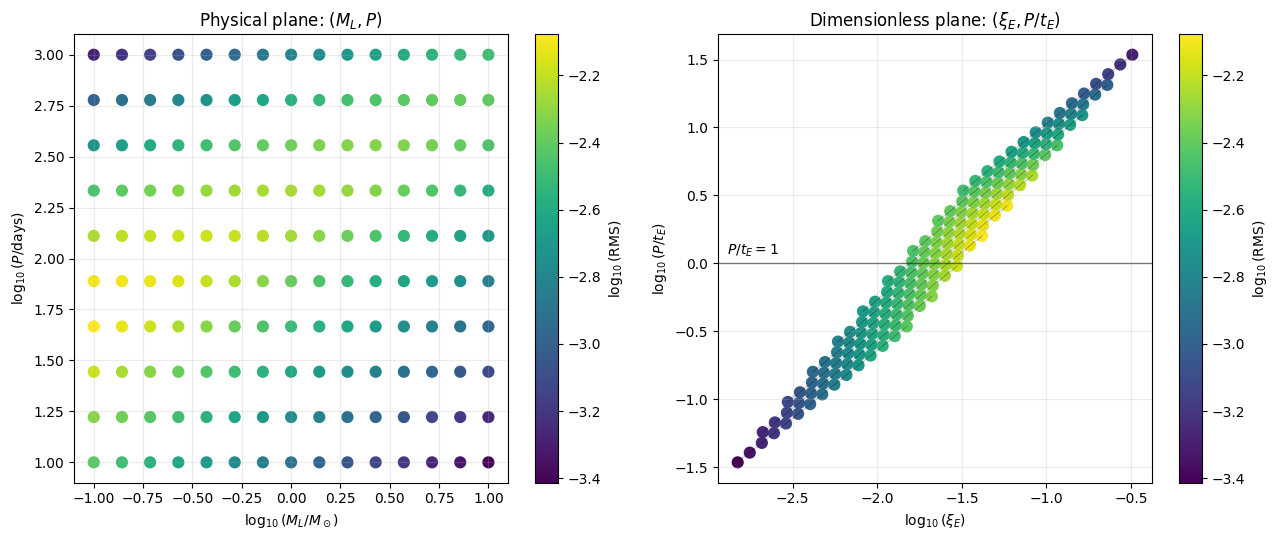

In [14]:
def scan_ML_P_grid(
    M_lens_array,
    P_array,
    mu_rel_masyr     = 4.0,
    Dl_kpc           = 4.0,
    Ds_kpc           = 8.0,
    Mtot_source_Msun = 2.0,
    q_mass           = 0.5,
    qflux            = 0.5,
    u0_true          = 0.3,
    t0_true          = 0.0,
    **kwargs
):
    results = []

    window_k = kwargs.get("window_k", 5.0)

    for P in P_array:
        for ML in M_lens_array:

            thetaE_mas, pi_rel_mas = thetaE_from_lens_mass(
                ML, Dl_kpc, Ds_kpc
            )

            tE_computed = thetaE_mas / mu_rel_masyr * 365.25

            out = compute_binary_source_case(
                P_days           = P,
                tE_true          = tE_computed,
                u0_true          = u0_true,
                t0_true          = t0_true,
                use_kepler       = True,
                Mtot_source_Msun = Mtot_source_Msun,
                M_lens_Msun      = ML,
                Dl_kpc           = Dl_kpc,
                Ds_kpc           = Ds_kpc,
                q_mass           = q_mass,
                qflux            = qflux,
                **kwargs
            )

            info = out["kepler_info"]

            results.append(dict(
                ML              = ML,
                P               = P,
                thetaE_mas      = thetaE_mas,
                pi_rel_mas      = pi_rel_mas,
                tE_days         = tE_computed,

                xiE             = out["xiE_use"],
                PtE             = P / tE_computed,
                tE_over_P       = tE_computed / P,
                n_orbits_window = 2.0 * window_k * tE_computed / P,

                RE_source_AU    = info["RE_source_AU"],
                a_rel_AU        = info["a_rel_AU"],
                a1_AU           = info["a1_AU"],
                a2_AU           = info["a2_AU"],

                rms             = out["rms_abs_resid_A"],
                max_resid       = out["max_abs_resid_A"],

                # parámetros verdaderos
                t0_true         = out["t0_true"],
                u0_true         = out["u0_true"],
                tE_true         = out["tE_true"],

                # parámetros ajustados por PSPL
                t0_fit          = out["t0_fit"],
                u0_fit          = out["u0_fit"],
                tE_fit          = out["tE_fit"],

                # diferencias absolutas
                delta_t0        = out["delta_t0"],
                delta_u0        = out["delta_u0"],
                delta_tE        = out["delta_tE"],

                # diferencias relativas
                frac_delta_tE   = out["frac_delta_tE"],
                frac_delta_u0   = out["frac_delta_u0"],

                # útil por la degeneración de signo de u0
                delta_abs_u0    = np.abs(out["u0_fit"]) - np.abs(out["u0_true"]),
                frac_delta_abs_u0 = (
                    np.abs(out["u0_fit"]) - np.abs(out["u0_true"])
                ) / np.abs(out["u0_true"]),
            ))

    return results

def plot_ML_P_diagnostics(results):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.DataFrame(results)

    df["logML"]  = np.log10(df["ML"])
    df["logP"]   = np.log10(df["P"])
    df["logxiE"] = np.log10(df["xiE"])
    df["logPtE"] = np.log10(df["PtE"])
    df["logrms"] = np.log10(df["rms"])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    ax = axes[0]

    sc0 = ax.scatter(
        df["logML"],
        df["logP"],
        c=df["logrms"],
        s=60,
        cmap="viridis"
    )

    ax.set_xlabel(r"$\log_{10}(M_L/M_\odot)$")
    ax.set_ylabel(r"$\log_{10}(P/{\rm days})$")
    ax.set_title(r"Physical plane: $(M_L, P)$")
    ax.grid(alpha=0.25)

    cbar0 = plt.colorbar(sc0, ax=ax)
    cbar0.set_label(r"$\log_{10}(\mathrm{RMS})$")

    ax = axes[1]

    sc1 = ax.scatter(
        df["logxiE"],
        df["logPtE"],
        c=df["logrms"],
        s=60,
        cmap="viridis"
    )

    for P_val, grp in df.groupby("P"):
        grp = grp.sort_values("ML")
        ax.plot(
            grp["logxiE"],
            grp["logPtE"],
            "k-",
            lw=0.7,
            alpha=0.25
        )

    for ML_val, grp in df.groupby("ML"):
        grp = grp.sort_values("P")
        ax.plot(
            grp["logxiE"],
            grp["logPtE"],
            "k--",
            lw=0.5,
            alpha=0.15
        )

    ax.axhline(0.0, color="k", lw=1.0, alpha=0.5)
    ax.text(
        0.02, 0.03,
        r"$P/t_E=1$",
        transform=ax.get_yaxis_transform(),
        ha="left",
        va="bottom"
    )

    ax.set_xlabel(r"$\log_{10}(\xi_E)$")
    ax.set_ylabel(r"$\log_{10}(P/t_E)$")
    ax.set_title(r"Dimensionless plane: $(\xi_E, P/t_E)$")
    ax.grid(alpha=0.25)

    cbar1 = plt.colorbar(sc1, ax=ax)
    cbar1.set_label(r"$\log_{10}(\mathrm{RMS})$")

    plt.tight_layout()
    plt.show()

    return df

def plot_ML_P_grid(results):
    import pandas as pd
    df = pd.DataFrame(results)

    fig, ax = plt.subplots(figsize=(8, 6))

    for P_val, grp in df.groupby("P"):
        sc = ax.scatter(
            np.log10(grp["xiE"]),
            np.log10(grp["PtE"]),
            c=np.log10(grp["rms"]),
            cmap="viridis", s=40,
            vmin=np.log10(df["rms"].min()),
            vmax=np.log10(df["rms"].max()),
        )
        ax.plot(
            np.log10(grp["xiE"]),
            np.log10(grp["PtE"]),
            "k-", lw=0.6, alpha=0.3
        )

    plt.colorbar(sc, ax=ax, label=r"$\log_{10}(\mathrm{RMS})$")
    ax.set_xlabel(r"$\log_{10}(\xi_E)$")
    ax.set_ylabel(r"$\log_{10}(P/t_E)$")
    ax.set_title(r"Grid $(M_L, P)$ in the plane $(\xi_E,\, P/t_E)$")
    ax.grid(alpha=0.2)
    plt.show()
def plot_fit_parameter_deltas_physical(results):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm

    df = pd.DataFrame(results)

    df["logML"] = np.log10(df["ML"])
    df["logP"]  = np.log10(df["P"])

    quantities = [
        ("delta_t0",        r"$\Delta t_0 = t_{0,\rm fit}-t_{0,\rm true}$ [days]"),
        ("delta_u0",        r"$\Delta u_0 = u_{0,\rm fit}-u_{0,\rm true}$"),
        ("frac_delta_tE",   r"$\Delta t_E/t_{E,\rm true}$"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

    for ax, (col, label) in zip(axes, quantities):

        vals = df[col].values

        vmax = np.nanmax(np.abs(vals))
        if vmax == 0 or not np.isfinite(vmax):
            vmax = 1.0

        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

        sc = ax.scatter(
            df["logML"],
            df["logP"],
            c=vals,
            s=65,
            cmap="coolwarm",
            norm=norm,
        )

        ax.set_xlabel(r"$\log_{10}(M_L/M_\odot)$")
        ax.set_ylabel(r"$\log_{10}(P/{\rm days})$")
        ax.set_title(label)
        ax.grid(alpha=0.25)

        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(label)

    plt.tight_layout()
    plt.show()

    return df

M_lens_array = np.logspace(-1, 1, 15)    # 0.1 a 10 Msun
P_array      = np.logspace(1, 3, 10)     # 10 a 1000 días

results_grid = scan_ML_P_grid(
    M_lens_array     = M_lens_array,
    P_array          = P_array,
    mu_rel_masyr     = 4.0,
    Dl_kpc           = 4.0,
    Ds_kpc           = 8.0,
    Mtot_source_Msun = 2.0,
    q_mass           = 0.5,
    qflux            = 0.0,
    u0_true          = 0.3,
    t0_true          = 0.0,
    theta            = 0.0,
    phi0             = np.pi,
    lambda_xi        = 0.0,
    xi_source        = "source1",
    n_points         = 3000,
    window_k         = 5.0,
)

df_grid = plot_ML_P_diagnostics(results_grid)


Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit 

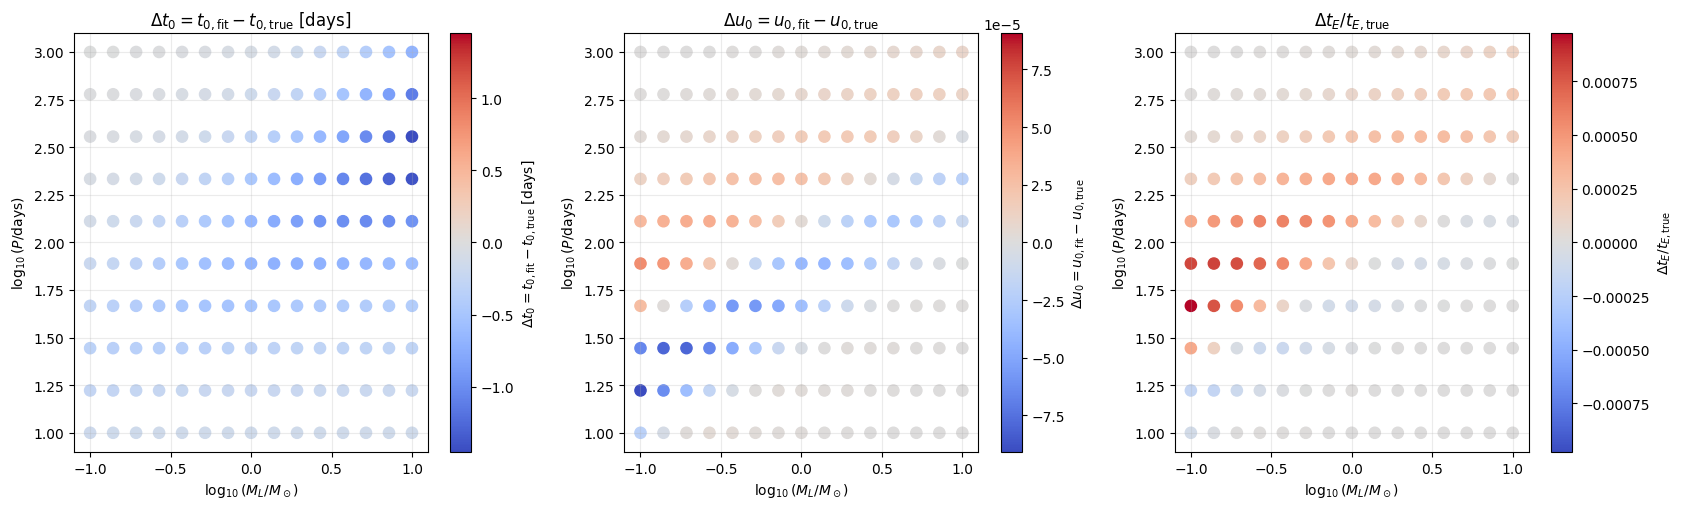

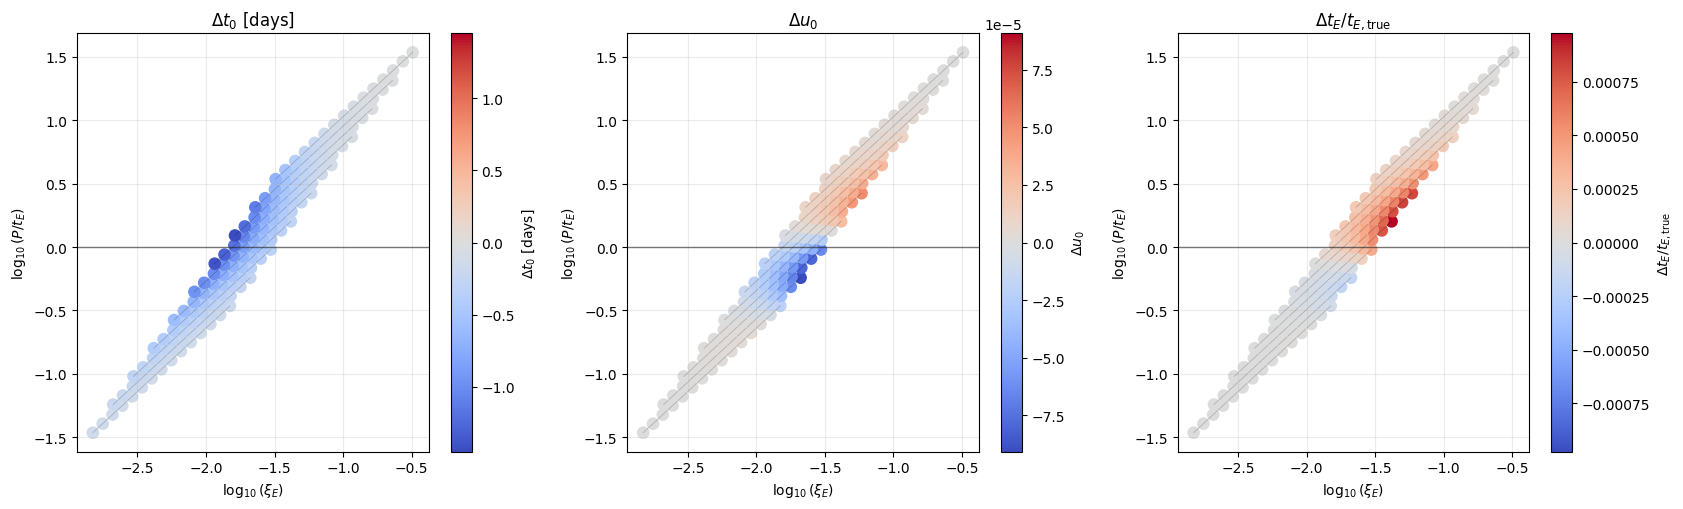

In [16]:
def plot_fit_parameter_deltas_dimensionless(results):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm

    df = pd.DataFrame(results)

    df["logxiE"] = np.log10(df["xiE"])
    df["logPtE"] = np.log10(df["PtE"])

    quantities = [
        ("delta_t0",        r"$\Delta t_0$ [days]"),
        ("delta_u0",        r"$\Delta u_0$"),
        ("frac_delta_tE",   r"$\Delta t_E/t_{E,\rm true}$"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

    for ax, (col, label) in zip(axes, quantities):

        vals = df[col].values

        vmax = np.nanmax(np.abs(vals))
        if vmax == 0 or not np.isfinite(vmax):
            vmax = 1.0

        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

        sc = ax.scatter(
            df["logxiE"],
            df["logPtE"],
            c=vals,
            s=65,
            cmap="coolwarm",
            norm=norm,
        )

        for P_val, grp in df.groupby("P"):
            grp = grp.sort_values("ML")
            ax.plot(
                np.log10(grp["xiE"]),
                np.log10(grp["PtE"]),
                "k-",
                lw=0.6,
                alpha=0.2,
            )

        ax.axhline(0.0, color="k", lw=1.0, alpha=0.5)

        ax.set_xlabel(r"$\log_{10}(\xi_E)$")
        ax.set_ylabel(r"$\log_{10}(P/t_E)$")
        ax.set_title(label)
        ax.grid(alpha=0.25)

        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(label)

    plt.tight_layout()
    plt.show()

    return df

M_lens_array = np.logspace(-1, 1, 15)
P_array      = np.logspace(1, 3, 10)

results_grid = scan_ML_P_grid(
    M_lens_array     = M_lens_array,
    P_array          = P_array,
    mu_rel_masyr     = 4.0,
    Dl_kpc           = 4.0,
    Ds_kpc           = 8.0,
    Mtot_source_Msun = 2.0,
    q_mass           = 0.5,
    qflux            = 0.0,
    u0_true          = 0.3,
    t0_true          = 0.0,
    theta            = 0.0,
    phi0             = np.pi,
    lambda_xi        = 0.0,
    xi_source        = "source1",
    n_points         = 3000,
    window_k         = 5.0,
)

df_delta_phys = plot_fit_parameter_deltas_physical(results_grid)

df_delta_dim = plot_fit_parameter_deltas_dimensionless(results_grid)

In [18]:
# ============================================================
# Barrido en lambda_xi y P para M_L fijo
# ============================================================

def scan_lambda_P_grid(
    lambda_xi_array,
    P_array,
    M_lens_fixed      = 1.0,
    mu_rel_masyr     = 4.0,
    Dl_kpc           = 4.0,
    Ds_kpc           = 8.0,
    Mtot_source_Msun = 2.0,
    q_mass           = 0.5,
    qflux            = 0.0,
    u0_true          = 0.3,
    t0_true          = 0.0,
    **kwargs
):
    """
    Barrido en lambda_xi y P para una masa de lente fija.

    Se mantiene fijo:
        M_L, D_L, D_S, mu_rel, Mtot_source, q_mass, qflux,
        u0, t0, theta, phi0, etc.

    Se cambia:
        lambda_xi y P.

    Para M_L fijo:
        theta_E, t_E y R_E,S son constantes.

    Para P variable:
        xi_E cambia por Kepler.
    """

    import numpy as np

    results = []

    kwargs = dict(kwargs)

    # Evita duplicar lambda_xi si lo pasaste por error en kwargs.
    kwargs.pop("lambda_xi", None)

    window_k = kwargs.get("window_k", 5.0)

    thetaE_mas, pi_rel_mas = thetaE_from_lens_mass(
        M_lens_fixed,
        Dl_kpc,
        Ds_kpc
    )

    tE_computed = thetaE_mas / mu_rel_masyr * 365.25

    for P in P_array:
        for lam in lambda_xi_array:

            out = compute_binary_source_case(
                P_days           = P,
                tE_true          = tE_computed,
                u0_true          = u0_true,
                t0_true          = t0_true,
                use_kepler       = True,
                Mtot_source_Msun = Mtot_source_Msun,
                M_lens_Msun      = M_lens_fixed,
                Dl_kpc           = Dl_kpc,
                Ds_kpc           = Ds_kpc,
                q_mass           = q_mass,
                qflux            = qflux,
                lambda_xi        = lam,
                **kwargs
            )

            info = out["kepler_info"]

            results.append(dict(
                ML              = M_lens_fixed,
                P               = P,
                lambda_xi       = lam,
                lambda_over_pi  = lam / np.pi,

                thetaE_mas      = thetaE_mas,
                pi_rel_mas      = pi_rel_mas,
                tE_days         = tE_computed,

                xiE             = out["xiE_use"],
                PtE             = P / tE_computed,
                tE_over_P       = tE_computed / P,
                n_orbits_window = 2.0 * window_k * tE_computed / P,

                RE_source_AU    = info["RE_source_AU"],
                a_rel_AU        = info["a_rel_AU"],
                a1_AU           = info["a1_AU"],
                a2_AU           = info["a2_AU"],

                rms             = out["rms_abs_resid_A"],
                max_resid       = out["max_abs_resid_A"],

                # parámetros verdaderos
                t0_true         = out["t0_true"],
                u0_true         = out["u0_true"],
                tE_true         = out["tE_true"],

                # parámetros ajustados por PSPL
                t0_fit          = out["t0_fit"],
                u0_fit          = out["u0_fit"],
                tE_fit          = out["tE_fit"],

                # diferencias absolutas
                delta_t0        = out["delta_t0"],
                delta_u0        = out["delta_u0"],
                delta_tE        = out["delta_tE"],

                # diferencias relativas
                frac_delta_tE   = out["frac_delta_tE"],
                frac_delta_u0   = out["frac_delta_u0"],

                # útil por degeneración de signo de u0
                delta_abs_u0    = np.abs(out["u0_fit"]) - np.abs(out["u0_true"]),
                frac_delta_abs_u0 = (
                    np.abs(out["u0_fit"]) - np.abs(out["u0_true"])
                ) / np.abs(out["u0_true"]),
            ))

    return results

In [20]:
# ============================================================
# Plot RMS en la grilla lambda_xi - P
# ============================================================

def plot_lambda_P_grid(results, color_col="rms", log_color=True):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.DataFrame(results)

    x = df["lambda_over_pi"]
    y = np.log10(df["P"])

    if log_color:
        c = np.log10(df[color_col])
        cbar_label = rf"$\log_{{10}}({color_col})$"
    else:
        c = df[color_col]
        cbar_label = color_col

    fig, ax = plt.subplots(figsize=(8, 6))

    sc = ax.scatter(
        x,
        y,
        c=c,
        s=65,
        cmap="viridis"
    )

    # Conectar puntos de P fijo
    for P_val, grp in df.groupby("P"):
        grp = grp.sort_values("lambda_xi")
        ax.plot(
            grp["lambda_over_pi"],
            np.log10(grp["P"]),
            "k-",
            lw=0.5,
            alpha=0.20
        )

    # Conectar puntos de lambda fijo
    for lam_val, grp in df.groupby("lambda_xi"):
        grp = grp.sort_values("P")
        ax.plot(
            grp["lambda_over_pi"],
            np.log10(grp["P"]),
            "k--",
            lw=0.5,
            alpha=0.12
        )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(cbar_label)

    ax.set_xlabel(r"$\lambda_\xi/\pi$")
    ax.set_ylabel(r"$\log_{10}(P/{\rm days})$")
    ax.set_title(rf"Grid in $(\lambda_\xi, P)$ for fixed $M_L={df['ML'].iloc[0]:.2f}\,M_\odot$")
    ax.grid(alpha=0.25)

    ax.set_xticks([0, 0.5, 1, 1.5, 2])
    ax.set_xticklabels([
        r"$0$",
        r"$\pi/2$",
        r"$\pi$",
        r"$3\pi/2$",
        r"$2\pi$"
    ])

    plt.tight_layout()
    plt.show()

    return df

# ============================================================
# Plot de Delta t0, Delta u0 y Delta tE/tE en lambda_xi - P
# ============================================================

def plot_lambda_P_fit_deltas(results, use_abs_u0=False):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm

    df = pd.DataFrame(results)

    if use_abs_u0:
        u0_col = "delta_abs_u0"
        u0_label = r"$\Delta |u_0|$"
    else:
        u0_col = "delta_u0"
        u0_label = r"$\Delta u_0$"

    quantities = [
        ("delta_t0",      r"$\Delta t_0$ [days]"),
        (u0_col,          u0_label),
        ("frac_delta_tE", r"$\Delta t_E/t_{E,\rm true}$"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

    for ax, (col, label) in zip(axes, quantities):

        vals = df[col].values.astype(float)

        vmax = np.nanmax(np.abs(vals))
        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0

        norm = TwoSlopeNorm(
            vmin=-vmax,
            vcenter=0.0,
            vmax=vmax
        )

        sc = ax.scatter(
            df["lambda_over_pi"],
            np.log10(df["P"]),
            c=vals,
            s=65,
            cmap="coolwarm",
            norm=norm
        )

        for P_val, grp in df.groupby("P"):
            grp = grp.sort_values("lambda_xi")
            ax.plot(
                grp["lambda_over_pi"],
                np.log10(grp["P"]),
                "k-",
                lw=0.5,
                alpha=0.20
            )

        for lam_val, grp in df.groupby("lambda_xi"):
            grp = grp.sort_values("P")
            ax.plot(
                grp["lambda_over_pi"],
                np.log10(grp["P"]),
                "k--",
                lw=0.5,
                alpha=0.12
            )

        ax.set_xlabel(r"$\lambda_\xi/\pi$")
        ax.set_ylabel(r"$\log_{10}(P/{\rm days})$")
        ax.set_title(label)
        ax.grid(alpha=0.25)

        ax.set_xticks([0, 0.5, 1, 1.5, 2])
        ax.set_xticklabels([
            r"$0$",
            r"$\pi/2$",
            r"$\pi$",
            r"$3\pi/2$",
            r"$2\pi$"
        ])

        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(label)

    plt.tight_layout()
    plt.show()

    return df

Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit success
Fit 

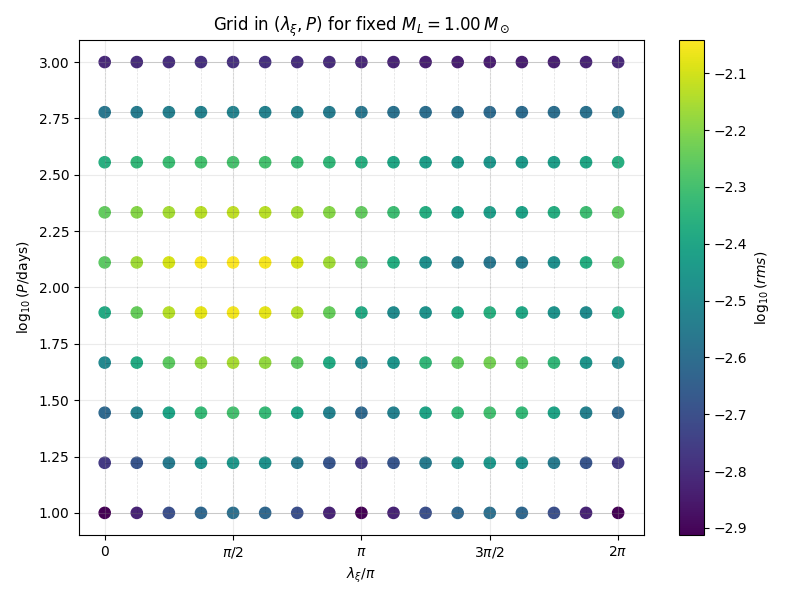

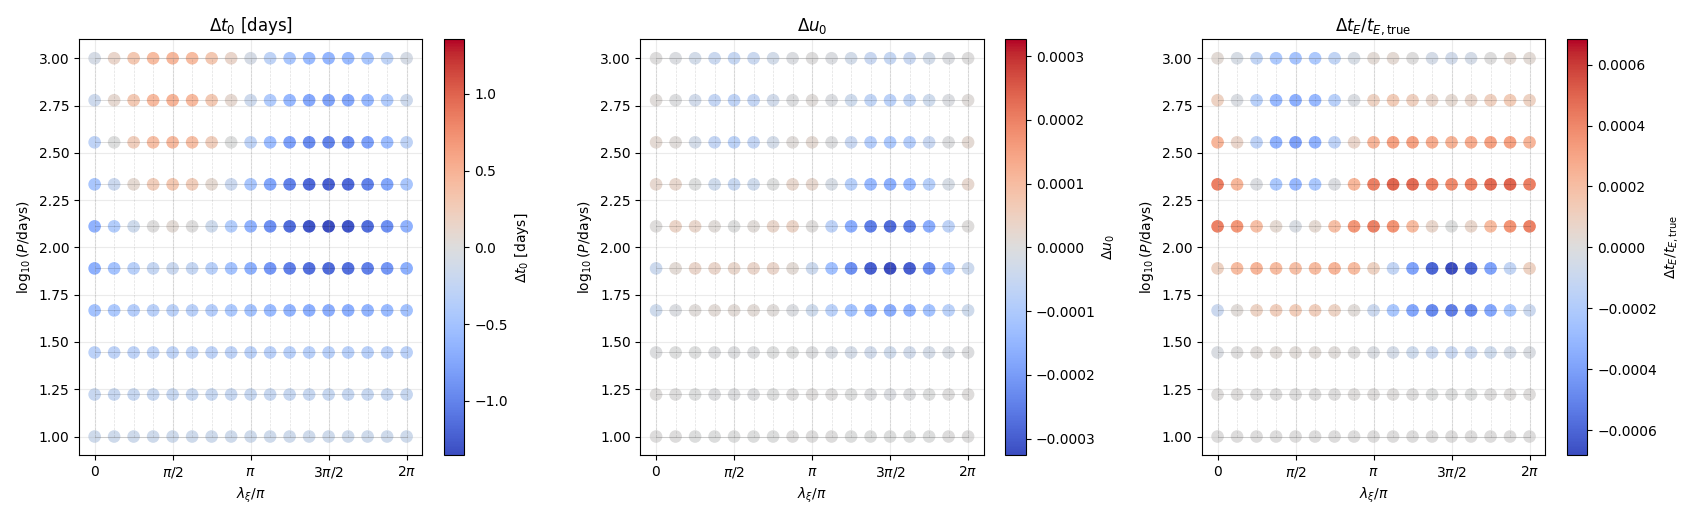

In [21]:
# ============================================================
# Ejecución: M_L fijo, barrido en lambda_xi y P
# ============================================================

M_lens_fixed = 1.0

lambda_xi_array = np.linspace(0.0, 2.0*np.pi, 17)
P_array = np.logspace(1, 3, 10)   # 10 a 1000 días

results_lambda_P = scan_lambda_P_grid(
    lambda_xi_array = lambda_xi_array,
    P_array         = P_array,

    M_lens_fixed    = M_lens_fixed,
    mu_rel_masyr    = 4.0,
    Dl_kpc          = 4.0,
    Ds_kpc          = 8.0,

    Mtot_source_Msun = 2.0,
    q_mass           = 0.5,
    qflux            = 0.0,

    u0_true          = 0.3,
    t0_true          = 0.0,

    theta            = 0.0,
    phi0             = np.pi,
    xi_source        = "source1",

    n_points         = 3000,
    window_k         = 5.0,
)

df_lambda_P = plot_lambda_P_grid(
    results_lambda_P,
    color_col="rms",
    log_color=True
)

df_lambda_P_deltas = plot_lambda_P_fit_deltas(
    results_lambda_P,
    use_abs_u0=False
)